# Exploratory Data Analysis — ACI-IoT-2023 Payload Dataset

This notebook explores the raw, per-packet payload dataset before any
modeling. Goal: understand what each column represents, how imbalanced the
classes are, what the numeric features look like per attack type, and
whether the data has any structural quirks (duplicates, timing patterns)
worth knowing about before building a model on it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")
project_root = Path.cwd().parent


## Load the dataset

In [2]:
df = pd.read_csv(project_root / "data/raw/ACI-IoT-2023-Payload.csv")
print(df.shape)
df.head()


(631486, 10)


,srcip,sport,dstip,dsport,protocol_m,sttl,total_len,payload,stime,label
0,192.168.1.81,60683,239.255.255.250,1900,udp,2,362,4e4f54494659202a20485454502f312e310d0a4e54533a...,1698670981,Benign
1,192.168.1.9,53160,239.255.255.250,1900,udp,1,204,4d2d534541524348202a20485454502f312e310d0a484f...,1698670984,Benign
2,192.168.1.9,53160,239.255.255.250,1900,udp,1,204,4d2d534541524348202a20485454502f312e310d0a484f...,1698670985,Benign
3,192.168.1.9,53160,239.255.255.250,1900,udp,1,204,4d2d534541524348202a20485454502f312e310d0a484f...,1698670986,Benign
4,192.168.1.9,53160,239.255.255.250,1900,udp,1,204,4d2d534541524348202a20485454502f312e310d0a484f...,1698670987,Benign


## Column overview

| Column | Type | What it represents |
|---|---|---|
| `srcip` | identity | Source IP address of the packet |
| `sport` | identity | Source port |
| `dstip` | identity | Destination IP address |
| `dsport` | identity | Destination port |
| `protocol_m` | categorical | Transport protocol (e.g. TCP, UDP, ICMP) |
| `sttl` | numeric | Source TTL (time-to-live) value in the packet header |
| `total_len` | numeric | Total length of the packet in bytes |
| `stime` | numeric (epoch time) | Timestamp the packet was captured |
| `payload` | raw text/hex | The packet's raw payload content |
| `label` | categorical (target) | Traffic type: Benign or a specific attack |

**Important framing for everything below:** `srcip`, `dstip`, `sport`,
`dsport`, `stime`, and `payload` are *identity/context* columns, not
necessarily safe model features -- they can let a model memorize which
capture session a row came from rather than learning general traffic
behavior. This EDA treats them as things to understand and visualize, not
as features to feed a model directly.

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 631486 entries, 0 to 631485
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   srcip       631486 non-null  str  
 1   sport       631486 non-null  int64
 2   dstip       631486 non-null  str  
 3   dsport      631486 non-null  int64
 4   protocol_m  631486 non-null  str  
 5   sttl        631486 non-null  int64
 6   total_len   631486 non-null  int64
 7   payload     631486 non-null  str  
 8   stime       631486 non-null  int64
 9   label       631486 non-null  str  
dtypes: int64(5), str(5)
memory usage: 48.2 MB


## Missing values

In [4]:
df.isnull().sum()


srcip         0
sport         0
dstip         0
dsport        0
protocol_m    0
sttl          0
total_len     0
payload       0
stime         0
label         0
dtype: int64

## Duplicate rows

A first pass check on exact duplicate rows across the *entire* raw
dataset (including identity columns) -- this is different from, and less
informative than, checking duplicates on modeling features alone (which is
covered in the leakage-specific analysis in the modeling notebook), but
it's a useful first signal of how repetitive the traffic is.

In [5]:
print(f"Fully duplicate rows: {df.duplicated().sum()} of {len(df)}")
print(f"Duplicate rows ignoring identity columns (protocol_m, sttl, total_len, payload, label): "
      f"{df.duplicated(subset=['protocol_m','sttl','total_len','payload','label']).sum()} of {len(df)}")


Fully duplicate rows: 3342 of 631486
Duplicate rows ignoring identity columns (protocol_m, sttl, total_len, payload, label): 47544 of 631486


## Target distribution: attack types

The core challenge of this dataset -- severe class imbalance. Benign
traffic vastly outnumbers most attack types, and some attack types are
themselves extremely rare relative to others.

In [6]:
label_counts = df["label"].value_counts()
label_counts


label
Benign                601868
DNS Flood              18577
Dictionary Attack       4645
Slowloris               2974
SYN Flood               2113
Port Scan                582
Vulnerability Scan       445
OS Scan                  156
UDP Flood                 68
ICMP Flood                58
Name: count, dtype: int64

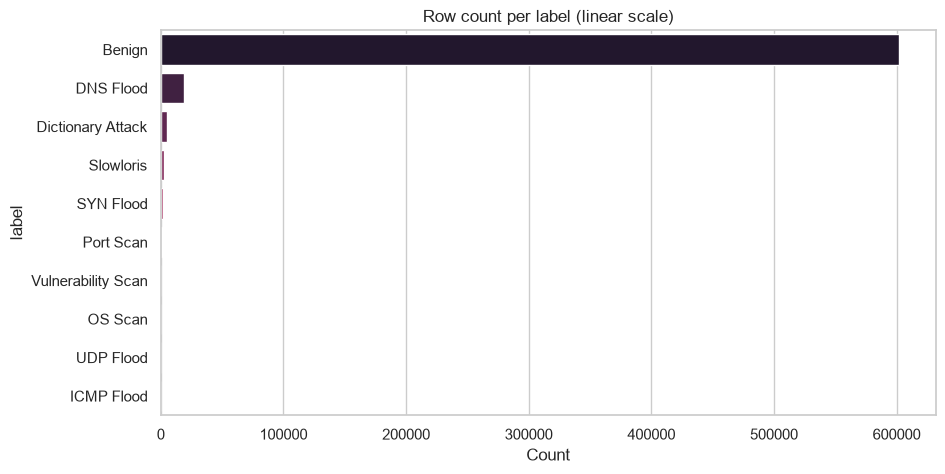

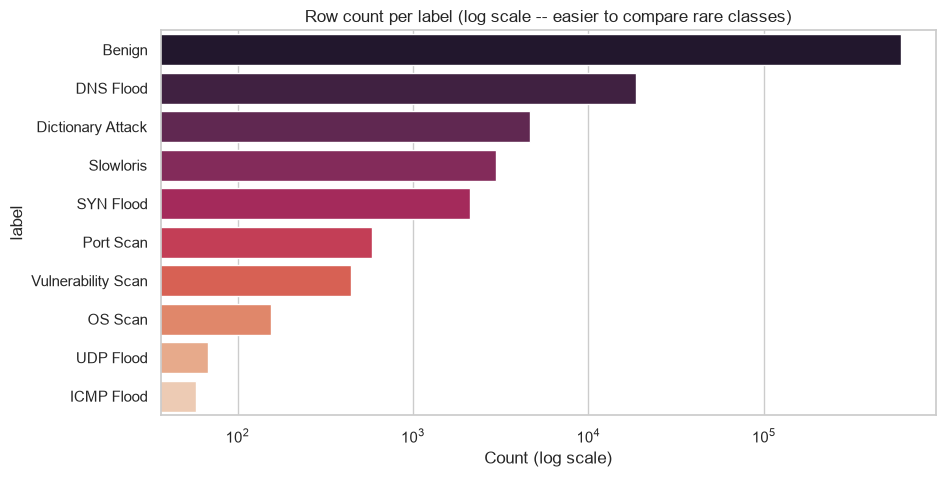

In [7]:
plt.figure(figsize=(10, 5))
sns.barplot(x=label_counts.values, y=label_counts.index, hue=label_counts.index, palette="rocket", legend=False)
plt.xlabel("Count")
plt.title("Row count per label (linear scale)")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x=label_counts.values, y=label_counts.index, hue=label_counts.index, palette="rocket", legend=False)
plt.xscale("log")
plt.xlabel("Count (log scale)")
plt.title("Row count per label (log scale -- easier to compare rare classes)")
plt.show()


## Benign vs. Attack (binary view)

Collapsing all attack subtypes into a single "Attack" class shows the
imbalance at its simplest level -- this is the framing used for a Stage 1
binary detector in the modeling notebook.

label_binary
Benign    601868
Attack     29618
Name: count, dtype: int64

Ratio: 20.3 Benign rows per Attack row


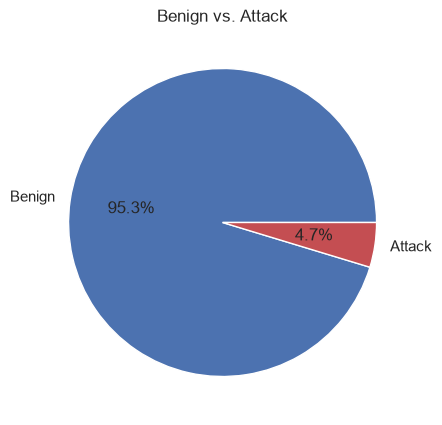

In [8]:
df["label_binary"] = np.where(df["label"] == "Benign", "Benign", "Attack")
binary_counts = df["label_binary"].value_counts()
print(binary_counts)
print(f"\nRatio: {binary_counts['Benign'] / binary_counts['Attack']:.1f} Benign rows per Attack row")

plt.figure(figsize=(5, 5))
plt.pie(binary_counts.values, labels=binary_counts.index, autopct="%1.1f%%", colors=["#4c72b0", "#c44e52"])
plt.title("Benign vs. Attack")
plt.show()


## Protocol distribution

How traffic protocol varies -- both overall and broken down by label, to
see whether certain attack types are strongly associated with a specific
protocol (a hint for feature usefulness later).

In [9]:
print(df["protocol_m"].value_counts())

protocol_by_label = pd.crosstab(df["label"], df["protocol_m"], normalize="index")
protocol_by_label


protocol_m
tcp      523628
udp      105235
other      2623
Name: count, dtype: int64


protocol_m,other,tcp,udp
label,,,
Benign,0.004262,0.852984,0.142754
DNS Flood,0.000000,0.000000,1.000000
Dictionary Attack,0.000000,1.000000,0.000000
ICMP Flood,1.000000,0.000000,0.000000
OS Scan,0.000000,0.000000,1.000000
Port Scan,0.000000,0.108247,0.891753
SYN Flood,0.000000,1.000000,0.000000
Slowloris,0.000000,1.000000,0.000000
UDP Flood,0.000000,0.058824,0.941176


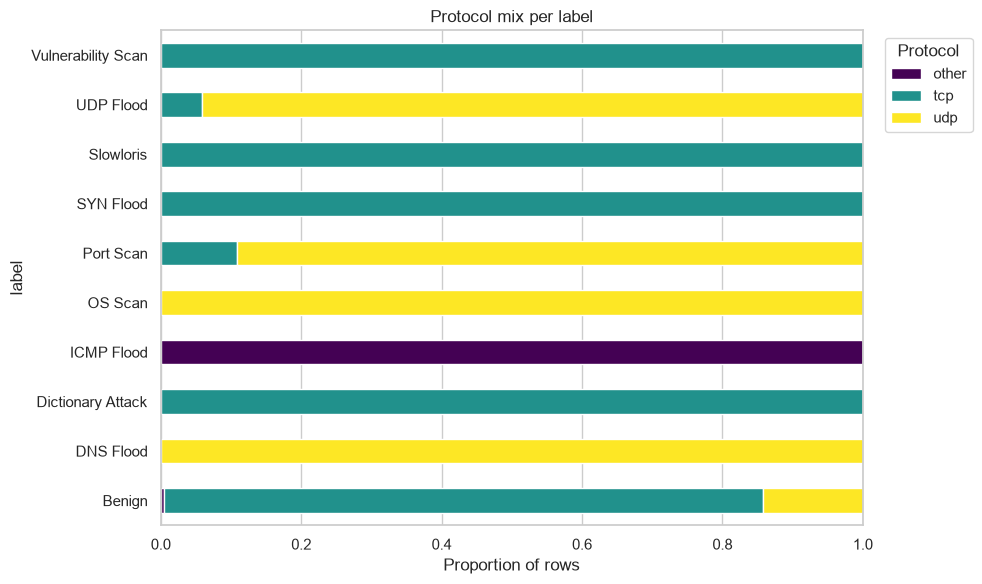

In [10]:
protocol_by_label.plot(kind="barh", stacked=True, figsize=(10, 6), colormap="viridis")
plt.xlabel("Proportion of rows")
plt.title("Protocol mix per label")
plt.legend(title="Protocol", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Numeric feature distributions: `sttl` and `total_len`

Distribution of the two core per-packet numeric features, overall and
split by label -- this is the first look at whether these features
actually separate attack types from Benign traffic, before any modeling.

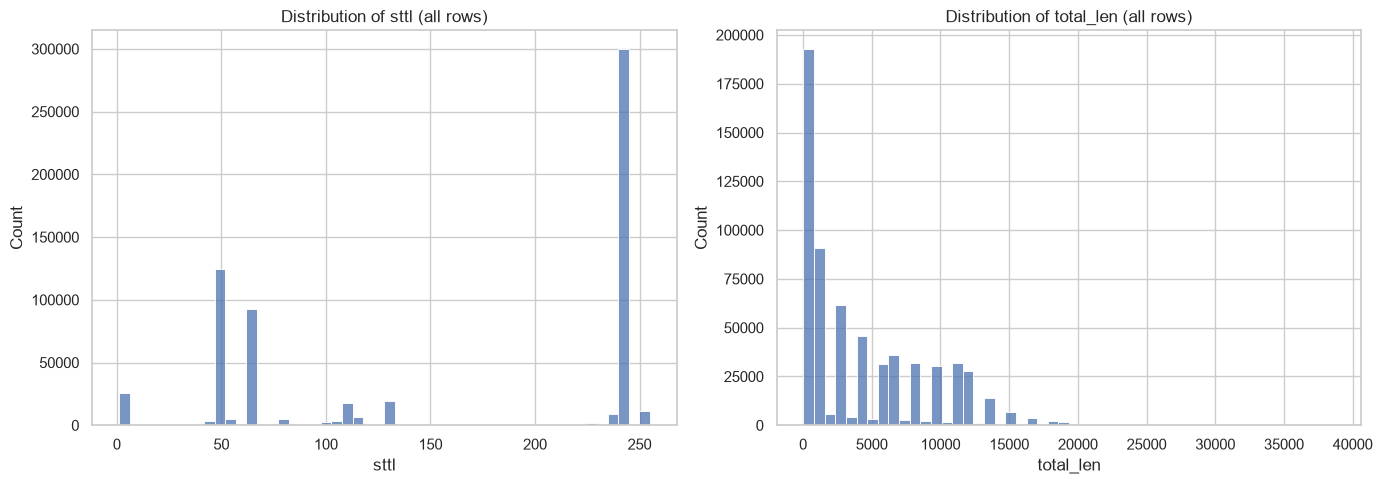

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["sttl"], bins=50, ax=axes[0])
axes[0].set_title("Distribution of sttl (all rows)")
sns.histplot(df["total_len"], bins=50, ax=axes[1])
axes[1].set_title("Distribution of total_len (all rows)")
plt.tight_layout()
plt.show()


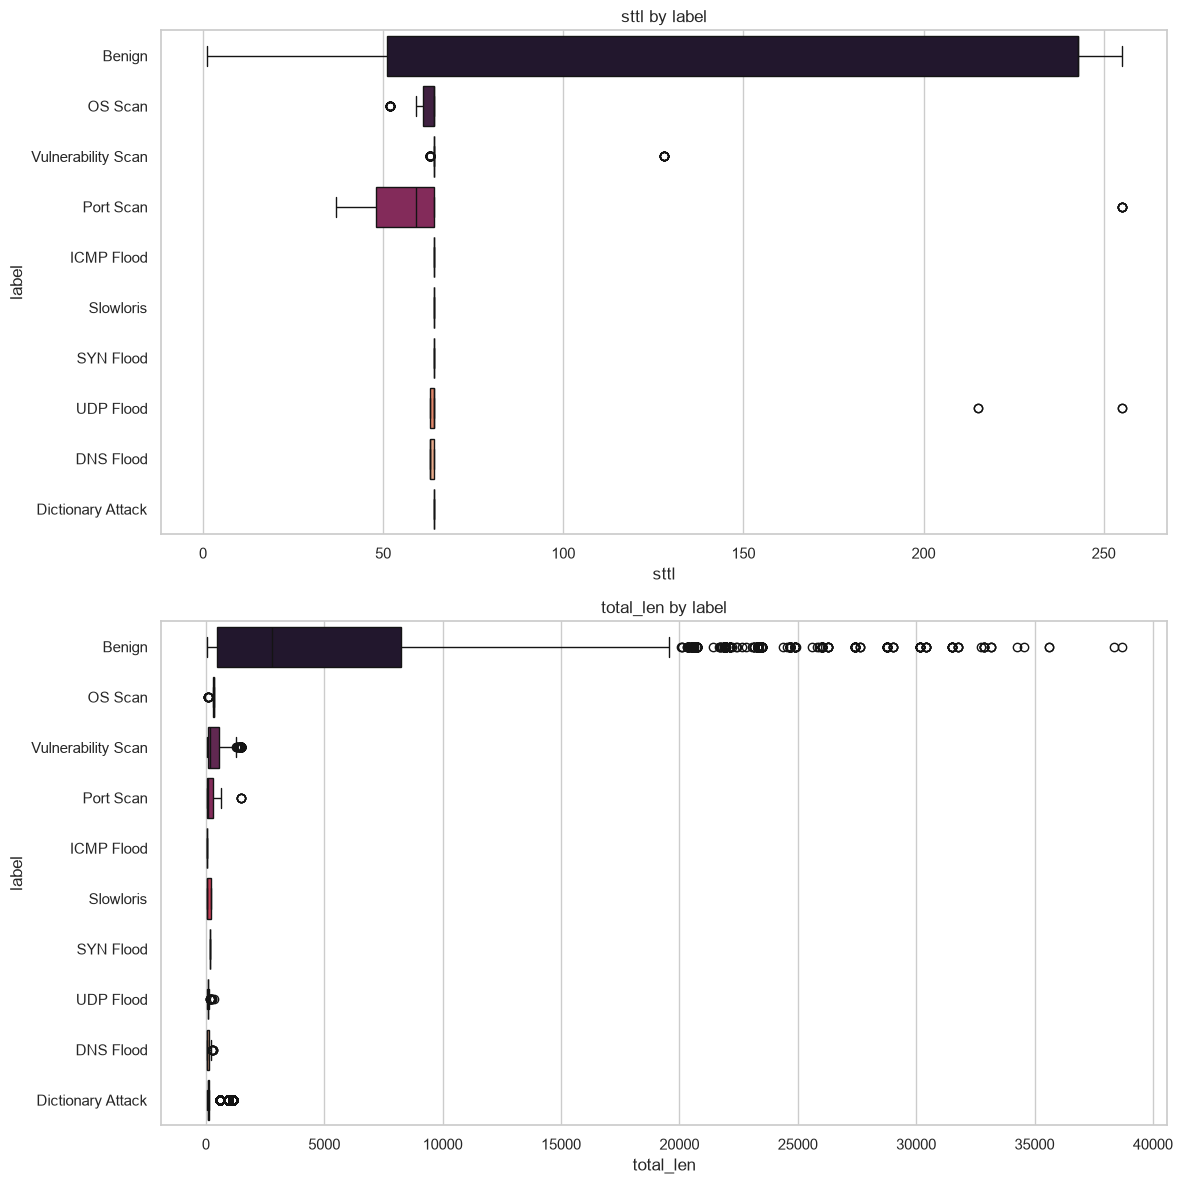

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

sns.boxplot(data=df, x="sttl", y="label", hue="label", ax=axes[0], palette="rocket", legend=False)
axes[0].set_title("sttl by label")

sns.boxplot(data=df, x="total_len", y="label", hue="label", ax=axes[1], palette="rocket", legend=False)
axes[1].set_title("total_len by label")

plt.tight_layout()
plt.show()


**What to look for above:** if a label's box sits clearly apart from
Benign's on either plot, that feature alone carries real separating power
for that attack type. If most labels overlap heavily with Benign, it's a
sign (confirmed later during modeling) that per-packet features alone
aren't enough to tell that attack apart, and time-window/behavioral
features would be needed.

## Correlation between numeric features

With only two raw numeric columns, this is a quick sanity check rather
than a rich analysis -- more meaningful once engineered window features
(packet rate, rolling mean/std) are added in the modeling notebook.

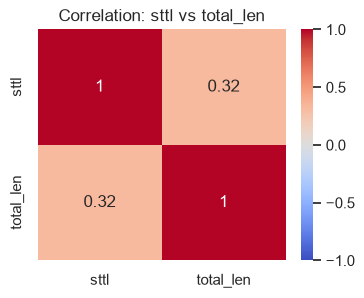

In [13]:
numeric_cols = ["sttl", "total_len"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(4, 3))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation: sttl vs total_len")
plt.show()


## Payload content: length distribution

The raw `payload` column is a hex/text string and should **not** be used
directly as a categorical feature (one-hot encoding it treats each
near-unique string as its own category, which acts like a row identifier
rather than a meaningful signal -- see the modeling notebook's leakage
discussion). Its *length*, however, may carry real signal and is safe to
look at.

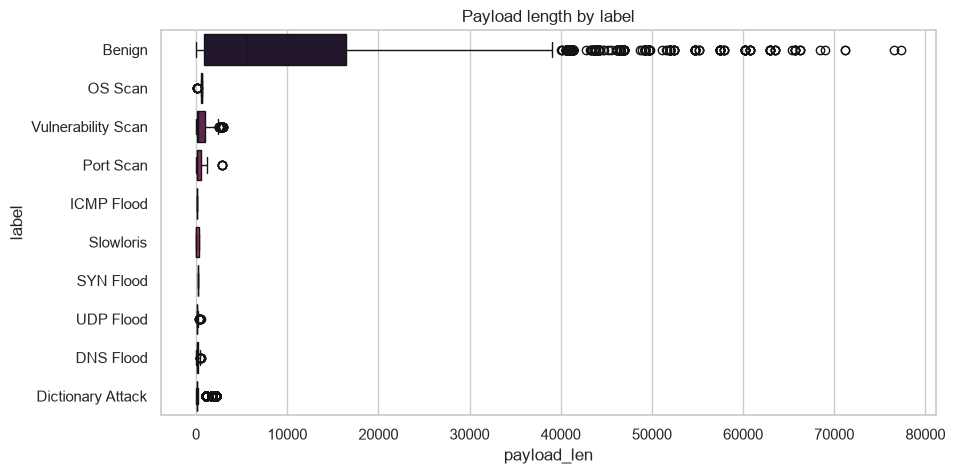

In [14]:
df["payload_len"] = df["payload"].astype(str).str.len()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="payload_len", y="label", hue="label", palette="rocket", legend=False)
plt.title("Payload length by label")
plt.show()


## Traffic volume over time

A view of overall packet volume across the capture timeline, and how each
label's traffic is distributed in time -- this is what first revealed
(during modeling) that some attack types are captured as a single
continuous burst rather than being spread across multiple separate
sessions, which has major implications for how the data can be validly
split into train/test.

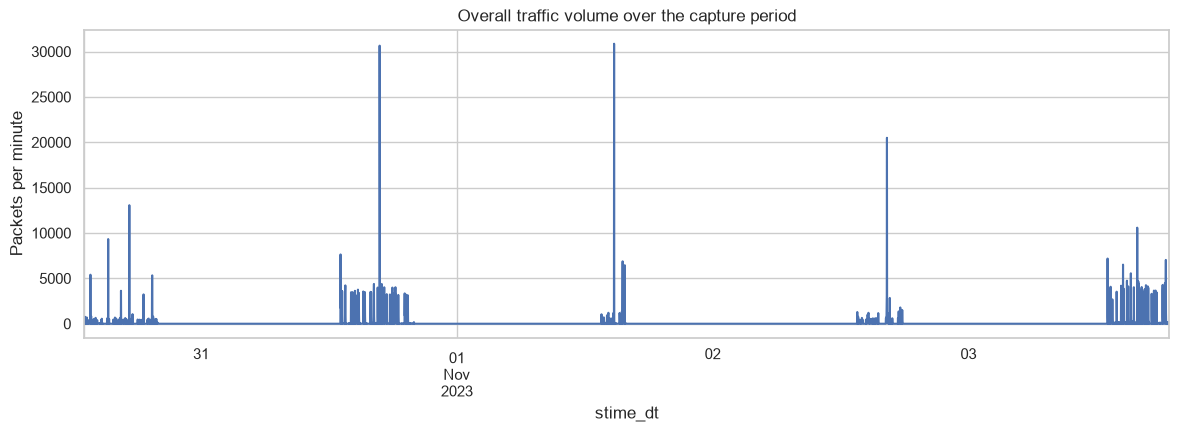

In [15]:
df["stime_dt"] = pd.to_datetime(df["stime"], unit="s")

plt.figure(figsize=(14, 4))
df.set_index("stime_dt").resample("1min").size().plot()
plt.ylabel("Packets per minute")
plt.title("Overall traffic volume over the capture period")
plt.show()


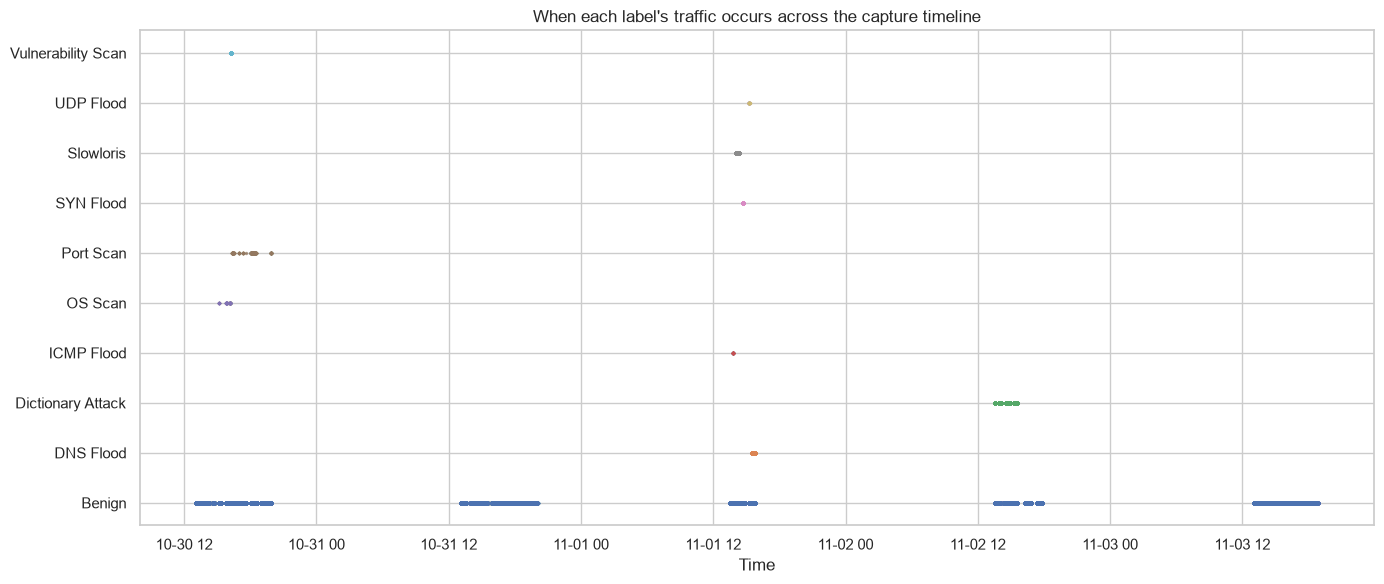

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))
for label, group in df.groupby("label"):
    ax.scatter(group["stime_dt"], [label] * len(group), s=2, alpha=0.4)
ax.set_title("When each label's traffic occurs across the capture timeline")
ax.set_xlabel("Time")
plt.tight_layout()
plt.show()


**What to look for above:** a label whose points form one tight, unbroken
cluster likely represents a single continuous attack session. A label
whose points appear in several visually separated clusters has multiple
independent sessions. This distinction matters a lot for modeling -- it
determines whether a class can be validly held out for testing at all
(quantified precisely via session-gap analysis in the modeling notebook).

## Session count per label (quick version)

A lightweight numeric version of the plot above: how many separate,
gap-isolated bursts each label appears in, and how many total rows/how
much time each spans. This single table is one of the most important
outputs of this whole exploration -- it flags upfront which classes will
support genuine train/test evaluation and which won't.

In [17]:
gap_threshold = 60  # seconds

session_summary = []
for label, group in df.groupby("label"):
    times = group.sort_values("stime")["stime"].values
    gaps = pd.Series(times).diff()
    n_sessions = (gaps > gap_threshold).sum() + 1
    span_min = (times[-1] - times[0]) / 60
    session_summary.append((label, n_sessions, len(group), span_min))

session_summary_df = pd.DataFrame(
    session_summary, columns=["label", "n_sessions", "n_rows", "span_minutes"]
).sort_values("n_sessions")

session_summary_df


,label,n_sessions,n_rows,span_minutes
3,ICMP Flood,1,58,0.966667
6,SYN Flood,1,2113,1.933333
9,Vulnerability Scan,1,445,0.150000
8,UDP Flood,1,68,1.950000
7,Slowloris,3,2974,16.750000
1,DNS Flood,4,18577,19.800000
4,OS Scan,4,156,57.816667
2,Dictionary Attack,13,4645,119.916667
5,Port Scan,15,582,213.450000
0,Benign,241,601868,6108.183333


## Summary of findings

- **Severe class imbalance**: Benign traffic dominates by orders of
  magnitude; some attack types (e.g. UDP Flood, ICMP Flood) have very few
  rows in absolute terms.
- **`sttl`/`total_len` alone show partial but incomplete separation**
  between labels -- some attack types are visually distinct, others
  overlap heavily with Benign, foreshadowing the recall ceiling seen for
  those classes during modeling.
- **The raw `payload` string is unsafe to use directly as a feature**, but
  its length is a legitimate, safe derived feature.
- **Traffic volume and session structure vary a lot by label** -- several
  attack types occur as a single, continuous capture burst rather than
  multiple independent sessions. This is a structural property of the
  dataset itself, not a modeling artifact, and constrains what kind of
  train/test split can produce trustworthy evaluation for those classes.

**Next steps (see the modeling notebook):** drop identity/raw columns
before training, engineer time-window features (packet rate, rolling
mean/std) to capture behavior across multiple packets rather than just one,
deduplicate before splitting, and split by session (not by a raw time
percentage) so that classes without multiple sessions are handled honestly
rather than silently leaking into an inflated test score.